# **UGST4158 — Introduction to Public Policy 2025/26 Winter**
# Central European University
## Difference-in-Differences: Effect of Milan's 2025 Smoking Ban on PM Levels

Quantitative Methods Seminar
- Liza Drini
- Benedek Szalma
- Zeteny Cseresznyes

**Design:** Milan (treated) vs Turin (control) · Treatment: Jan 2, 2025 · Weekly aggregation · City + week FE · HC1 robust SE

### 0. Modules

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
import re

### 1. Data Loading

#### 1.1. Milan

In [29]:
pm_cols  = ['pm2.5_atm', 'pm10.0_atm']
env_cols = ['temperature', 'humidity']
keep     = pm_cols + env_cols

milan_raw = pd.read_csv('../Data/milan_air_quality.csv')
milan_raw['time_stamp'] = pd.to_datetime(milan_raw['time_stamp'], unit='s').dt.strftime('%Y-%m-%d')

# outlier treatment on raw per-sensor data using sensors 6540 and 31569 as reference
# (these are the two sensors confirmed to be functioning correctly)
GOOD_SENSORS = [6540, 31569]
ref      = milan_raw[milan_raw['sensor_index'].isin(GOOD_SENSORS)]
ref_mean = ref[pm_cols].mean()
ref_std  = ref[pm_cols].std()

for col in pm_cols:
    lo = ref_mean[col] - 3 * ref_std[col]
    hi = ref_mean[col] + 3 * ref_std[col]
    milan_raw.loc[(milan_raw[col] < lo) | (milan_raw[col] > hi), col] = np.nan

milan_raw[pm_cols] = milan_raw.groupby('sensor_index')[pm_cols].transform(lambda s: s.interpolate(method='linear'))

# average across sensors → one clean row per day
milan = milan_raw.groupby('time_stamp')[keep].mean().reset_index()
milan['city']  = 'Milan'
milan['treat'] = 1
milan.head()

,time_stamp,pm2.5_atm,pm10.0_atm,temperature,humidity,city,treat
0,2022-01-01,89.85,104.20,48.5,57.5,Milan,1
1,2022-01-02,83.35,97.00,50.0,60.0,Milan,1
2,2022-01-03,53.70,67.70,49.5,63.5,Milan,1
3,2022-01-04,52.35,67.95,52.5,67.0,Milan,1
4,2022-01-05,35.95,45.05,52.5,59.0,Milan,1


#### 1.2. Turin

In [30]:
turin_raw = pd.read_csv('../Data/turin_air_quality.csv')
turin_raw['time_stamp'] = pd.to_datetime(turin_raw['time_stamp'], unit='s').dt.strftime('%Y-%m-%d')

turin = turin_raw.groupby('time_stamp')[keep].mean().reset_index()

# single sensor — use rolling median ± 2×MAD for outlier treatment
WINDOW, K = 30, 2.0
for col in pm_cols:
    s        = turin[col]
    roll_med = s.rolling(window=WINDOW, center=True, min_periods=7).median()
    roll_mad = (s - roll_med).abs().rolling(window=WINDOW, center=True, min_periods=7).median()
    bad      = (s < roll_med - K * roll_mad) | (s > roll_med + K * roll_mad)
    turin.loc[bad, col] = np.nan

turin[pm_cols] = turin[pm_cols].interpolate(method='linear')

turin['city']  = 'Turin'
turin['treat'] = 0
turin.head()

,time_stamp,pm2.5_atm,pm10.0_atm,temperature,humidity,city,treat
0,2022-02-24,40.100,49.900,56.0,34.0,Turin,0
1,2022-02-25,30.900,37.700,58.0,28.0,Turin,0
2,2022-02-26,31.725,38.475,56.0,14.0,Turin,0
3,2022-02-27,32.550,39.250,53.0,23.0,Turin,0
4,2022-03-01,33.375,40.025,47.0,31.0,Turin,0


#### 1.3. Panel Dataset

In [31]:
panel = pd.concat([milan, turin], ignore_index=True)
panel['date'] = pd.to_datetime(panel['time_stamp'])
panel = panel.sort_values(['city', 'date']).reset_index(drop=True)

print(panel.groupby('city')['date'].agg(['min', 'max', 'count']))
panel.head()

             min        max  count
city                              
Milan 2022-01-01 2025-12-30   1413
Turin 2022-02-24 2025-12-30   1357


,time_stamp,pm2.5_atm,pm10.0_atm,temperature,humidity,city,treat,date
0,2022-01-01,89.85,104.20,48.5,57.5,Milan,1,2022-01-01
1,2022-01-02,83.35,97.00,50.0,60.0,Milan,1,2022-01-02
2,2022-01-03,53.70,67.70,49.5,63.5,Milan,1,2022-01-03
3,2022-01-04,52.35,67.95,52.5,67.0,Milan,1,2022-01-04
4,2022-01-05,35.95,45.05,52.5,59.0,Milan,1,2022-01-05


### 2. Treatment Variables and Weekly Aggregation

In [32]:
TREAT_DATE = pd.Timestamp('2025-01-02')

panel['post'] = (panel['date'] >= TREAT_DATE).astype(int)
panel['did']  = panel['treat'] * panel['post']

# weekly aggregation reduces day-to-day measurement noise
panel['week'] = panel['date'].dt.to_period('W').dt.start_time

df_w = panel.groupby(['city', 'treat', 'week']).agg(
    pm25=('pm2.5_atm',  'mean'),
    pm10=('pm10.0_atm', 'mean'),
    temperature=('temperature', 'mean'),
    humidity=('humidity',    'mean'),
).reset_index()

df_w['post']     = (df_w['week'] >= TREAT_DATE).astype(int)
df_w['did']      = df_w['treat'] * df_w['post']
df_w['week_str'] = df_w['week'].dt.strftime('%Y-%W')

print(df_w.groupby(['city', 'post']).size().rename('n_weeks'))
df_w.head()

city   post
Milan  0       158
       1        52
Turin  0       150
       1        52
Name: n_weeks, dtype: int64


,city,treat,week,pm25,pm10,temperature,humidity,post,did,week_str
0,Milan,1,2021-12-27,86.600000,100.600000,49.250000,58.750000,0,0,2021-52
1,Milan,1,2022-01-03,49.300000,61.014286,49.071429,55.785714,0,0,2022-01
2,Milan,1,2022-01-10,63.250000,77.100000,49.214286,42.785714,0,0,2022-02
3,Milan,1,2022-01-17,74.621429,91.300000,50.214286,49.642857,0,0,2022-03
4,Milan,1,2022-01-24,61.507143,78.192857,48.928571,51.000000,0,0,2022-04


### 3. Parallel Trends Check

#### 3.1. Visual Check

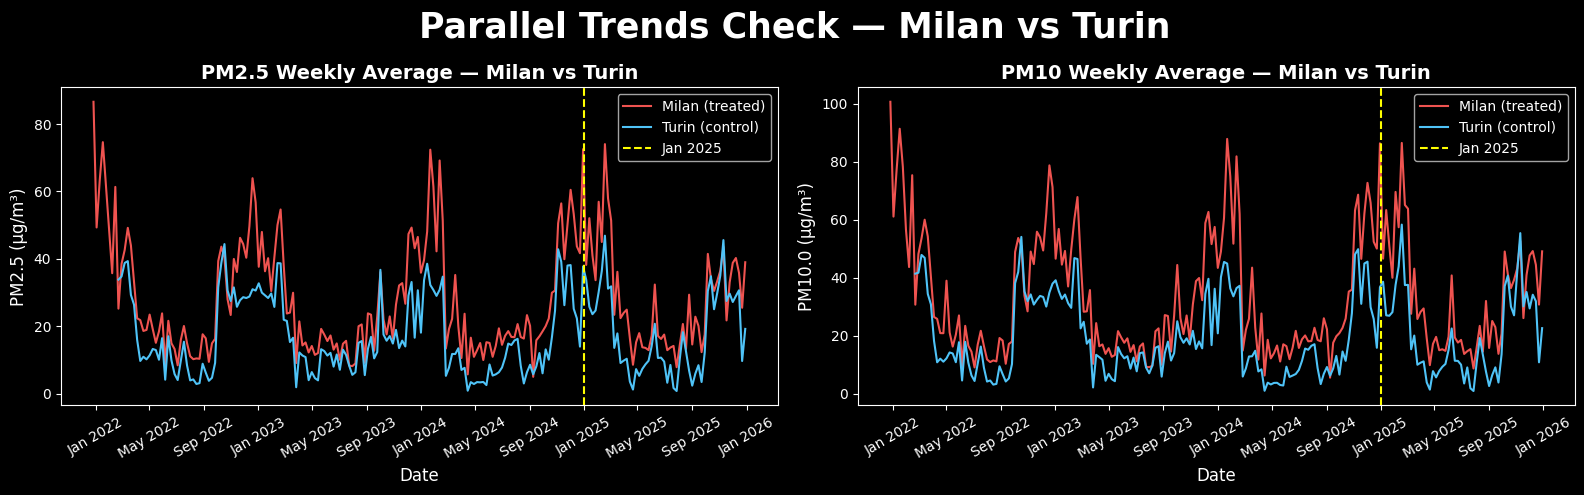

In [33]:
milan_w = df_w[df_w['city'] == 'Milan'].set_index('week')
turin_w = df_w[df_w['city'] == 'Turin'].set_index('week')

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, col, ylabel in zip(axes,
                                ['pm25', 'pm10'],
                                ['PM2.5 (µg/m³)', 'PM10.0 (µg/m³)']):
        ax.plot(milan_w.index, milan_w[col], color='#66bb6a', linewidth=1.5, label='Milan (treated)')
        ax.plot(turin_w.index, turin_w[col], color='#87ceeb', linewidth=1.5, label='Turin (control)')
        ax.axvline(TREAT_DATE, color='yellow', linestyle='--', linewidth=1.5, label='Jan 2025')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.legend(fontsize=10)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(False)

    axes[0].set_title('PM2.5 Weekly Average — Milan vs Turin', fontsize=14, fontweight='bold')
    axes[1].set_title('PM10 Weekly Average — Milan vs Turin', fontsize=14, fontweight='bold')

    fig.suptitle('Parallel Trends Check — Milan vs Turin', fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../Figures/parallel_trends_milan_turin.png', dpi=150, bbox_inches='tight')
    plt.show()

#### 3.2. Pre-Trend Formal Test

In [34]:
# restrict to pre-treatment period only
# if trends are parallel, treat×time interaction should be insignificant
pre = df_w[df_w['post'] == 0].copy()
pre['t'] = (pre['week'] - pre['week'].min()).dt.days / 7  # week index

if len(pre) > 0:
    res_pre = smf.ols('pm25 ~ treat * t + temperature + humidity', data=pre).fit(cov_type='HC1')
    coef = res_pre.params.get('treat:t', np.nan)
    pval = res_pre.pvalues.get('treat:t', np.nan)
    print(f'pre-trend interaction (treat × time):')
    print(f'  coefficient : {coef:.4f}')
    print(f'  p-value     : {pval:.4f}')
    print(f'  → {"parallel trends plausible" if pval > 0.1 else "WARNING: significant pre-trend"}')
else:
    print('no pre-treatment data available — parallel trends assumption cannot be tested')

pre-trend interaction (treat × time):
  coefficient : 0.0060
  p-value     : 0.8374
  → parallel trends plausible


### 4. Difference-in-Differences Regression

#### 4.1. PM2.5

In [35]:
# did coefficient = ATT (average treatment effect on the treated)
# city FE absorbs time-invariant city-level differences
# week FE absorbs common time shocks and seasonality
# note: with only 2 cities, clustering at city level is infeasible — HC1 robust SE used instead
formula_pm25 = 'pm25 ~ did + temperature + humidity + C(city) + C(week_str)'
res_pm25 = smf.ols(formula_pm25, data=df_w).fit(cov_type='HC1')

# show only the key coefficients
key = ['did', 'temperature', 'humidity']
print(res_pm25.summary2().tables[1].loc[[c for c in key if c in res_pm25.params.index]])
print(f'\nR² = {res_pm25.rsquared:.3f}   N = {int(res_pm25.nobs)}')

                Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
did          1.704727  1.256416  1.356817  0.174839 -0.757803  4.167257
temperature -0.811448  0.378594 -2.143320  0.032087 -1.553479 -0.069418
humidity     0.349209  0.110689  3.154870  0.001606  0.132263  0.566155

R² = 0.949   N = 412


c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 213, but rank is 206
  warnings.warn('covariance of constraints does not have full '


#### 4.2. PM10

In [36]:
formula_pm10 = 'pm10 ~ did + temperature + humidity + C(city) + C(week_str)'
res_pm10 = smf.ols(formula_pm10, data=df_w).fit(cov_type='HC1')

key = ['did', 'temperature', 'humidity']
print(res_pm10.summary2().tables[1].loc[[c for c in key if c in res_pm10.params.index]])
print(f'\nR² = {res_pm10.rsquared:.3f}   N = {int(res_pm10.nobs)}')

                Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
did          1.923431  1.508115  1.275387  0.202172 -1.032421  4.879283
temperature -0.824311  0.434015 -1.899269  0.057529 -1.674965  0.026343
humidity     0.528869  0.137971  3.833180  0.000126  0.258450  0.799288

R² = 0.949   N = 412


c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 213, but rank is 206
  warnings.warn('covariance of constraints does not have full '


### 5. Event Study

c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\regression\linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
c:\Users\Hp\miniconda3\envs\dsp-d\Lib\site-packages\statsmodels\regression\linear_model.py:1970: RuntimeWarning: invalid value encountered in dot
  H = np.dot(self.model.pinv_wexog,


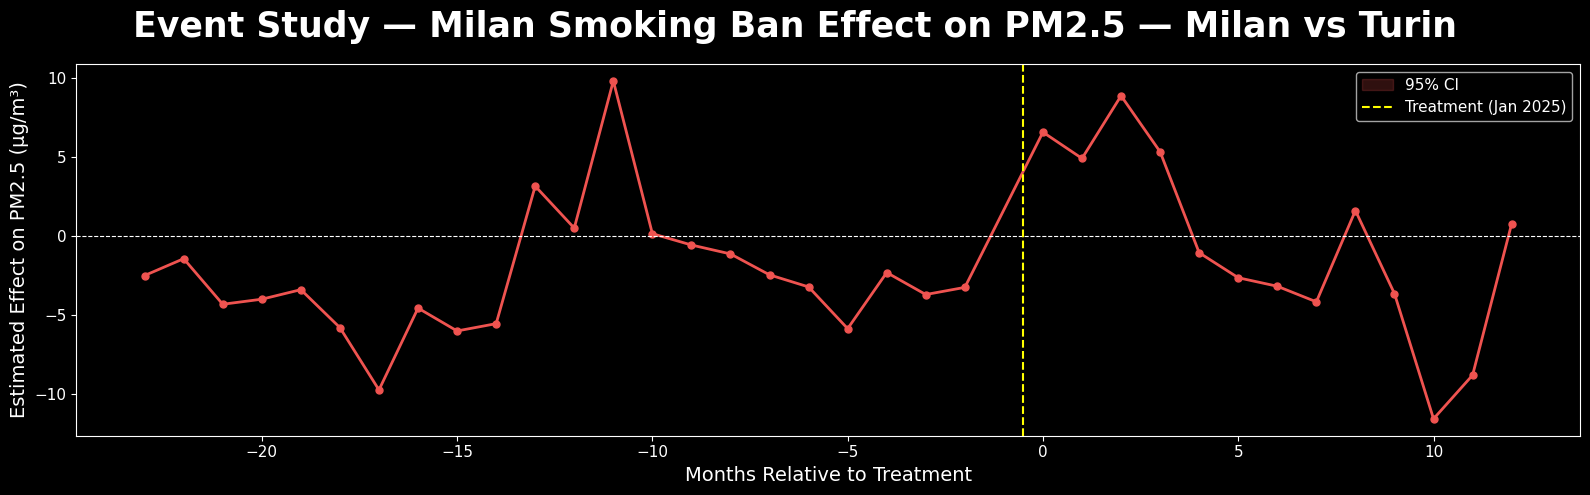

In [37]:
# monthly bins relative to treatment (month 0 = Jan 2025)
panel['rel_month'] = ((panel['date'] - TREAT_DATE) / pd.Timedelta(days=30.44)).round().astype(int)
panel['rel_month'] = panel['rel_month'].clip(-24, 12)

df_m = panel.groupby(['city', 'treat', 'rel_month']).agg(
    pm25=('pm2.5_atm', 'mean'),
    temperature=('temperature', 'mean'),
    humidity=('humidity', 'mean'),
).reset_index()

# omit rel_month == -1 as reference period
df_es = df_m[df_m['rel_month'] != -1].copy()

res_es = smf.ols('pm25 ~ C(rel_month)*treat + temperature + humidity + C(city)', data=df_es).fit(cov_type='HC1')

# extract treat × month interaction coefficients
pat = re.compile(r'C\(rel_month\)\[T\.([-\d]+)\]:treat')
event_coefs = {int(m.group(1)): res_es.params[k]
               for k in res_es.params.index for m in [pat.match(k)] if m}
event_ci    = {int(m.group(1)): res_es.conf_int().loc[k]
               for k in res_es.params.index for m in [pat.match(k)] if m}

if event_coefs:
    months = sorted(event_coefs)
    coefs  = [event_coefs[mo] for mo in months]
    ci_lo  = [event_ci[mo][0] for mo in months]
    ci_hi  = [event_ci[mo][1] for mo in months]

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(months, coefs, color='#66bb6a', linewidth=2, marker='o', markersize=5)
        ax.fill_between(months, ci_lo, ci_hi, color='#66bb6a', alpha=0.2, label='95% CI')
        ax.axhline(0,    color='white',  linewidth=0.8, linestyle='--')
        ax.axvline(-0.5, color='yellow', linewidth=1.5, linestyle='--', label='Treatment (Jan 2025)')
        ax.set_xlabel('Months Relative to Treatment', fontsize=14)
        ax.set_ylabel('Estimated Effect on PM2.5 (µg/m³)', fontsize=14)
        ax.legend(fontsize=11)
        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.grid(False)
        fig.suptitle('Event Study — Milan Smoking Ban Effect on PM2.5 — Milan vs Turin', fontsize=25, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../Figures/event_study_pm25_milan_turin.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('not enough data across treatment periods for event study')

### 6. Results

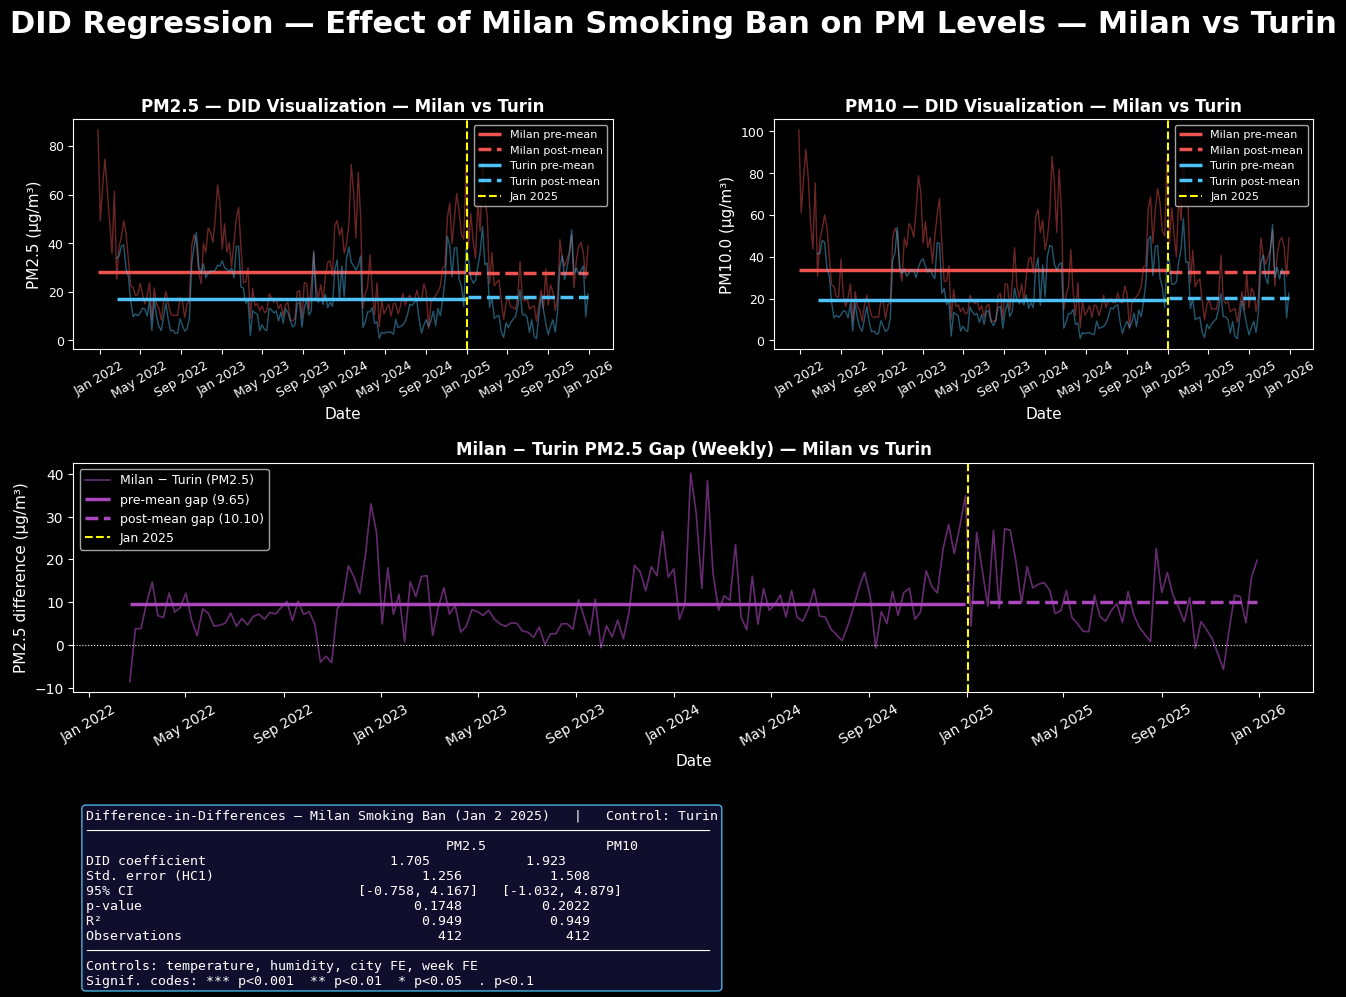

In [38]:
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '.'
    return ''

did25  = res_pm25.params['did'];       se25  = res_pm25.bse['did']
p25    = res_pm25.pvalues['did'];      ci25  = res_pm25.conf_int().loc['did']
did10  = res_pm10.params['did'];       se10  = res_pm10.bse['did']
p10    = res_pm10.pvalues['did'];      ci10  = res_pm10.conf_int().loc['did']

result_text = (
    f"Difference-in-Differences — Milan Smoking Ban (Jan 2 2025)   |   Control: Turin\n"
    f"{'─'*78}\n"
    f"{'':32s}  {'PM2.5':>16s}   {'PM10':>16s}\n"
    f"{'DID coefficient':32s}  {did25:>9.3f} {stars(p25):<4s}   {did10:>9.3f} {stars(p10):<4s}\n"
    f"{'Std. error (HC1)':32s}  {se25:>13.3f}   {se10:>13.3f}\n"
    f"{'95% CI':32s}  [{ci25[0]:6.3f},{ci25[1]:6.3f}]   [{ci10[0]:6.3f},{ci10[1]:6.3f}]\n"
    f"{'p-value':32s}  {p25:>13.4f}   {p10:>13.4f}\n"
    f"{'R\u00b2':32s}  {res_pm25.rsquared:>13.3f}   {res_pm10.rsquared:>13.3f}\n"
    f"{'Observations':32s}  {int(res_pm25.nobs):>13d}   {int(res_pm10.nobs):>13d}\n"
    f"{'─'*78}\n"
    f"Controls: temperature, humidity, city FE, week FE\n"
    f"Signif. codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1"
)

with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(16, 11))
    gs  = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.4], hspace=0.55, wspace=0.3)

    ax_pm25 = fig.add_subplot(gs[0, 0])
    ax_pm10 = fig.add_subplot(gs[0, 1])
    ax_diff = fig.add_subplot(gs[1, :])
    ax_txt  = fig.add_subplot(gs[2, :])
    ax_txt.axis('off')

    # --- top panels: weekly series + pre/post group means ---
    for ax, col, ylabel, title in [
        (ax_pm25, 'pm25', 'PM2.5 (µg/m³)', 'PM2.5 — DID Visualization — Milan vs Turin'),
        (ax_pm10, 'pm10', 'PM10.0 (µg/m³)', 'PM10 — DID Visualization — Milan vs Turin'),
    ]:
        for city_name, color in [('Milan', '#66bb6a'), ('Turin', '#87ceeb')]:
            cd   = df_w[df_w['city'] == city_name]
            pre  = cd[cd['post'] == 0]
            post = cd[cd['post'] == 1]
            ax.plot(cd['week'], cd[col], color=color, linewidth=1, alpha=0.45)
            if len(pre):  ax.hlines(pre[col].mean(),  pre['week'].min(),  pre['week'].max(),
                                    color=color, linewidth=2.5, label=f'{city_name} pre-mean')
            if len(post): ax.hlines(post[col].mean(), post['week'].min(), post['week'].max(),
                                    color=color, linewidth=2.5, linestyle='--', label=f'{city_name} post-mean')
        ax.axvline(TREAT_DATE, color='yellow', linewidth=1.5, linestyle='--', label='Jan 2025')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.grid(False)

    # --- middle panel: DID gap (Milan − Turin weekly) ---
    milan_w2 = df_w[df_w['city'] == 'Milan'].set_index('week')[['pm25', 'post']]
    turin_w2 = df_w[df_w['city'] == 'Turin'].set_index('week')[['pm25']]
    gap = (milan_w2['pm25'] - turin_w2['pm25']).dropna()
    gap_pre  = gap[milan_w2.reindex(gap.index)['post'] == 0]
    gap_post = gap[milan_w2.reindex(gap.index)['post'] == 1]

    ax_diff.plot(gap.index, gap, color='#ab47bc', linewidth=1.2, alpha=0.6, label='Milan − Turin (PM2.5)')
    if len(gap_pre):  ax_diff.hlines(gap_pre.mean(),  gap_pre.index.min(),  gap_pre.index.max(),
                                     color='#ab47bc', linewidth=2.5, label=f'pre-mean gap ({gap_pre.mean():.2f})')
    if len(gap_post): ax_diff.hlines(gap_post.mean(), gap_post.index.min(), gap_post.index.max(),
                                     color='#ab47bc', linewidth=2.5, linestyle='--', label=f'post-mean gap ({gap_post.mean():.2f})')
    ax_diff.axhline(0,          color='white',  linewidth=0.8, linestyle=':')
    ax_diff.axvline(TREAT_DATE, color='yellow', linewidth=1.5, linestyle='--', label='Jan 2025')
    ax_diff.set_title('Milan − Turin PM2.5 Gap (Weekly) — Milan vs Turin', fontsize=12, fontweight='bold')
    ax_diff.set_xlabel('Date', fontsize=11)
    ax_diff.set_ylabel('PM2.5 difference (µg/m³)', fontsize=11)
    ax_diff.legend(fontsize=9)
    ax_diff.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax_diff.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_diff.tick_params(axis='x', rotation=30, labelsize=10)
    ax_diff.tick_params(axis='y', labelsize=10)
    ax_diff.grid(False)

    # --- bottom: regression results textbox ---
    ax_txt.text(0.01, 0.98, result_text,
                transform=ax_txt.transAxes,
                fontsize=9.5, verticalalignment='top', fontfamily='monospace',
                color='white',
                bbox=dict(boxstyle='round', facecolor='#111133', edgecolor='#87ceeb', alpha=0.9))

    fig.suptitle('DID Regression — Effect of Milan Smoking Ban on PM Levels — Milan vs Turin',
                 fontsize=22, fontweight='bold')
    plt.savefig('../Figures/did_results_milan_turin.png', dpi=150, bbox_inches='tight')
    plt.show()